<a href="https://colab.research.google.com/github/gilIolgenblum/CrowdingModeWorkshop/blob/main/tutorials/solutions/E2_fitting_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3: Statistical Excercise

With excercise you will use what you learned about the statistical workflow to assess fit quality, and estimate uncertainty.

We will use the same system as in excercise E2:
**System:** AQ16 protein in Sucrose solution.
- **AQ16:** SASA = 242.6 Å²  
- **Sucrose:** $\nu = 11.9$, $\chi = 0.452$, $\chi_{TS} = -0.854$

> ⚠️ **This is the solution notebook.** Students should attempt the exercises independently first.

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/CrowdingModeWorkshop.git
    # Change the working directory to the repository root
    os.chdir('/content/CrowdingModeWorkshop')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/CrowdingModeWorkshop/src')

In [2]:
import crowding as cr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

---
## Task C1 — Load and Inspect the Data and Fit the Model

Repeat the analysis from exercise E2, so that you have a fully fitted model.

In [3]:
import os
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), "../../fh_crowding_workshop", "app", "sample_data", "aq16_sucrose_binary_format1.csv")
# On Colab: DATA_PATH = "https://raw.githubusercontent.com/gilIolgenblum/CrowdingModeWorkshop/main/app/sample_data/aq16_sucrose_binary_format1.csv"

df = pd.read_csv(DATA_PATH)
AQ16 = cr.Protein(SASA=242.6)
sucrose = cr.Cosolute(nu=11.9, chi=0.452, chiTS=-0.854)

model = cr.CrowdingModel(
    protein=AQ16, cosolute=sucrose,
    eps=0.0, epsTS=0.0,
    phiC_max=0.25, dphiC=0.001
)

exp_conc = df["concentration"].values
exp_ddG  = df["dG"].values
exp_ddH  = df["dH"].values
exp_TddS = df["TdS"].values

model.fit_eps(exp_conc, exp_ddG, concentration_type="molal")
model.fit_epsTS(exp_conc, exp_ddH, exp_TddS, concentration_type="molal")

Optimization terminated successfully.
         Current function value: 0.002809
         Iterations: 5
         Function evaluations: 16
         Gradient evaluations: 8
Optimization terminated successfully.
         Current function value: 0.377407
         Iterations: 1
         Function evaluations: 6
         Gradient evaluations: 3


---
## Task C2 — Evaluate Fit Quality (RMSE)

The model produces a **continuous curve** over a fine $\phi$ grid. Your experimental data sits at discrete concentration points.

**Steps:**
1. Convert the experimental **molal** concentrations to volume fraction $\phi$ using `model.molal` and `model.phiC` arrays (use `np.interp` to invert the mapping).
2. Interpolate the model's **$\Delta\Delta G^0$ curve** at the experimental $\phi$ values.
3. Compute the **Root Mean Squared Error (RMSE)** between the interpolated model and the experimental $\Delta\Delta G^0$.
4. Print the RMSE value.

**Question (answer below):** Is the RMSE acceptable for biophysical data? What would you do if it were too large?

In [4]:
# Convert experimental molal concentrations -> volume fraction
exp_phi = np.interp(exp_conc, model.molal, model.phiC)
print(exp_conc,exp_phi)

# Interpolate model ΔΔG⁰ at experimental phi values
model_ddG_at_exp = np.interp(exp_phi, model.phiC, model.ddA_kj)

# RMSE
rmse = np.sqrt(np.mean((model_ddG_at_exp - exp_ddG)**2))
print(f"RMSE(ΔΔG⁰) = {rmse:.4f} kJ/mol")

[0.35503 0.64347 0.88245 1.08369 1.25547] [0.07067267 0.12113503 0.15897168 0.1883947  0.21192911]
RMSE(ΔΔG⁰) = 0.0237 kJ/mol


---
## Task C3 — Uncertainty via Monte Carlo Subsampling

**Steps:**
1. Define a function that fits `eps` on a subset of the experimental data.
2. Pass this function to `cr.monte_carlo_subsampling()` — run **50 iterations**, retaining **50%** of data points.
3. Report the **mean** and **standard deviation** of the distribution of fitted `eps` values.
4. Plot histogram of the values of `eps`

Monte Carlo Subsampling:   0%|          | 0/50 [00:00<?, ?it/s]

eps = -0.0692 ± 0.0027 kJ/mol (mean ± std, n=50)


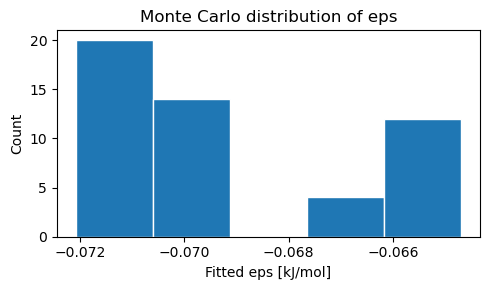

In [5]:
def fit_and_extract_eps(idx):
    # 1. Slice the experimental arrays using the randomized indices
    sub_conc = exp_conc[idx]
    sub_ddG = exp_ddG[idx]
    
    # 2. Run the fit silently
    model.fit_eps(sub_conc, sub_ddG, concentration_type='molal', disp=False, progress_bar=False, auto_solve=False)
    return {'eps': model.eps}
 
# This will take a few seconds
results = cr.monte_carlo_subsampling(
    n_points=len(exp_conc),
    fit_and_extract=fit_and_extract_eps,
    n_iterations=50,
    subsample_fraction=0.5,
    progress_bar=True
)

eps_values = results["eps"].values
print(f"eps = {eps_values.mean():.4f} ± {eps_values.std():.4f} kJ/mol (mean ± std, n=50)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(eps_values, bins=5, edgecolor="white")
ax.set_xlabel("Fitted eps [kJ/mol]")
ax.set_ylabel("Count")
ax.set_title("Monte Carlo distribution of eps")
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.tight_layout()
plt.show()


---
## Task C4 — Impact of the Number of Iterations on Uncertainty

**Steps:**
1. Repeat the analysis from Task B5 using several different numbers of iterations.
2. Plot the estimated uncertainty as a function of the number of iterations.
3. Examine how the uncertainty changes as the number of iterations increases.

**Question:**  
How many iterations are required for the estimated uncertainty to converge?

In [6]:
iterators = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 35, 50, 75, 100, 200, 300, 400, 500]#, 1000, 2000]

unc = []
for iterator in iterators:
    results = cr.monte_carlo_subsampling(
    n_points=len(exp_conc),
    fit_and_extract=fit_and_extract_eps,
    n_iterations=iterator,
    subsample_fraction=0.5,
    progress_bar=True
    )
    unc.append(results["eps"].values.std())


Monte Carlo Subsampling:   0%|          | 0/1 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/2 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/3 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/4 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/5 [00:00<?, ?it/s]

...

Monte Carlo Subsampling:   0%|          | 0/100 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/200 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/300 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/400 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/500 [00:00<?, ?it/s]

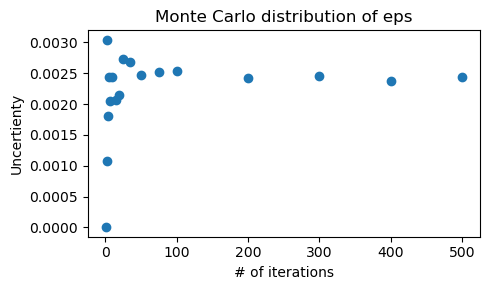

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(iterators, unc, 'o')
ax.set_xlabel("# of iterations")
ax.set_ylabel("Uncertienty")
ax.set_title("Monte Carlo distribution of eps")
plt.tight_layout()
plt.show()

For #iteractions>50 the uncertienty seems converged.

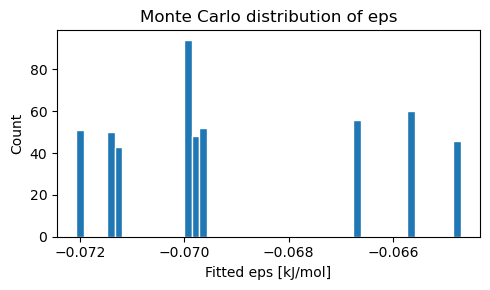

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(results["eps"].values, bins=50, edgecolor="white")
ax.set_xlabel("Fitted eps [kJ/mol]")
ax.set_ylabel("Count")
ax.set_title("Monte Carlo distribution of eps")
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.tight_layout()
plt.show()